
kb241226_00119
Slicer:              Large
Slice scale:         1.350 arcsec
Position scale:      0.294 arcsec
Detection wavelength: 3751.0 - 5573.0 A

Fitted source ellipse:
  center x:          15.253 arcsec
  center y:          9.923 arcsec
  semi-major axis:   10.250 arcsec
  semi-minor axis:   7.414 arcsec
  IFU-plane angle:   -174.40 deg

Detector pixels masked: 1,235,435
Valid IFU area masked:   36.28%
Written: /Volumes/Mainframe/KCWI/KcwiKit_Redux/redux/kb241226_00119_smsk_auto.fits


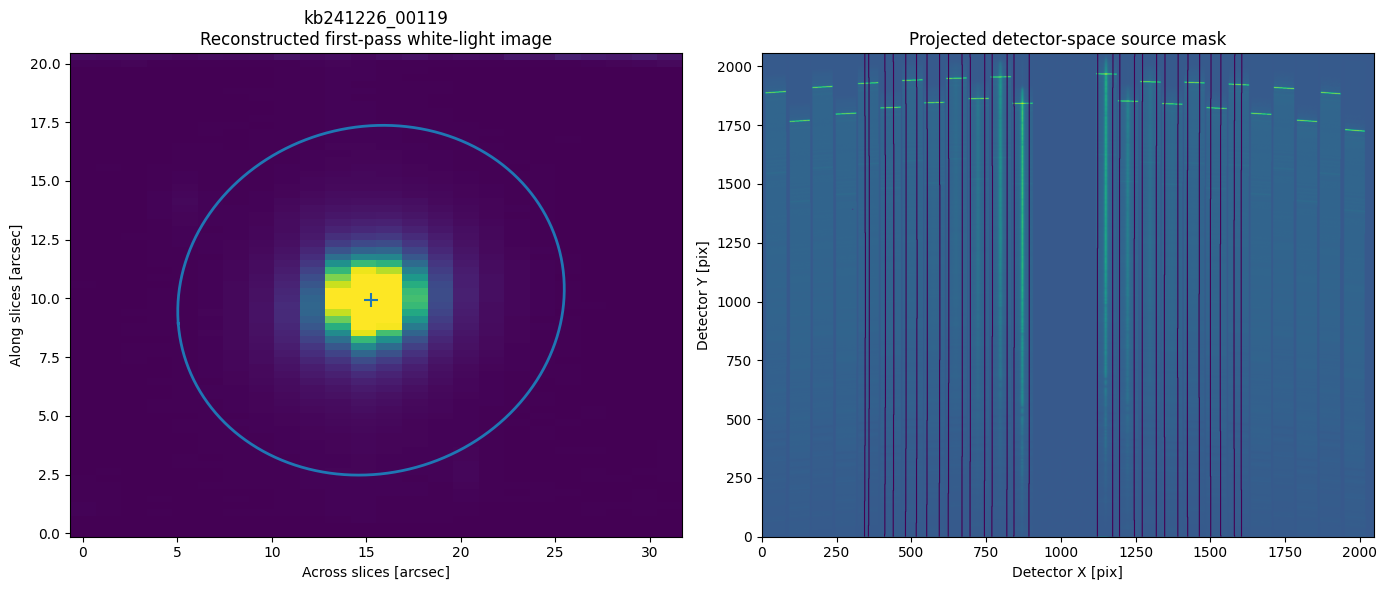

In [3]:
"""
Create the region mask around the galaxy continuum.
"""

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from scipy.ndimage import gaussian_filter, label
from scipy.linalg import eigh


# ============================================================
# USER SETTINGS
# ============================================================

REDUX = Path("/Volumes/Mainframe/KCWI/KcwiKit_Redux/redux")

# Put all blue science frames here.
# Examples:
FRAME_ROOTS = [
    "kb241226_00119",
    # "kb241226_00120",
    # "kb241226_00121",
]

# Detection settings
DETECT_SIGMA = 3.0

# Approximate Gaussian smoothing scale in arcsec for the
# reconstructed white-light image.
SMOOTH_ARCSEC = 0.6

# Expand the automatically detected source ellipse.
# >1 is intentional because we want to protect faint galaxy
# outskirts from entering the sky model.
ELLIPSE_EXPAND = 1.40

# Ignore this fraction of the wavelength range at each end
# when constructing the detection image.
WAVE_EDGE_FRAC = 0.05

# Output files are initially diagnostic rather than replacing
# any existing official smsk file.
MASK_SUFFIX = "_smsk_auto.fits"

SAVE_QC = True
SHOW_QC = True


# ============================================================
# KCWI geometry helpers
# ============================================================

def parse_binning(header):
    """
    Return the first detector binning value from the KCWI BINNING keyword.

    KCWI geometry uses this for the spatial pixel scale along a slice.
    """
    val = str(header.get("BINNING", "1,1"))
    val = val.replace("x", ",").replace("X", ",")
    try:
        return int(val.split(",")[0].strip())
    except Exception:
        return 1


def get_slicer_name(header):
    """
    Try common KCWI keywords for slicer/IFU name.
    """
    for key in ["IFUNAM", "IFUNAME", "IFU", "SLICER"]:
        if key in header:
            return str(header[key]).strip()
    return "Unknown"


def get_spatial_scales(header):
    """
    Approximate spatial scales in arcsec.

    Across slices:
        Small  ~0.35"
        Medium ~0.69"
        Large  ~1.35"

    Along slices:
        ~0.147"/unbinned detector pixel, multiplied by spatial binning.
    """

    slicer = get_slicer_name(header).lower()

    if "small" in slicer:
        slice_scale = 0.35
    elif "medium" in slicer or "med" in slicer:
        slice_scale = 0.69
    elif "large" in slicer:
        slice_scale = 1.35
    else:
        raise ValueError(
            f"Could not identify slicer from header. "
            f"Found slicer string: {get_slicer_name(header)!r}"
        )

    xbin = parse_binning(header)

    # KCWI nominal detector plate scale along the slices
    pos_scale = 0.147 * xbin

    return slice_scale, pos_scale


# ============================================================
# Find exact geometry maps associated with a science exposure
# ============================================================

def find_geometry_files(root):
    """
    Prefer geometry filenames recorded in the first-pass *_sky.fits
    header. This avoids accidentally using geometry from a different
    KCWI setup.
    """

    skyfile = REDUX / f"{root}_sky.fits"

    if not skyfile.exists():
        raise FileNotFoundError(
            f"Missing {skyfile}\n"
            "The first-pass sky product is useful because its header "
            "records the geometry files used by the DRP."
        )

    sh = fits.getheader(skyfile, 0)

    keys = {
        "wavemap": "WAVMAPF",
        "slicemap": "SLIMAPF",
        "posmap": "POSMAPF",
    }

    files = {}

    for name, key in keys.items():
        fn = sh.get(key)

        if fn is None:
            raise KeyError(
                f"{skyfile.name} does not contain header keyword {key}."
            )

        path = REDUX / Path(str(fn)).name

        if not path.exists():
            raise FileNotFoundError(
                f"{key} says {fn}, but I cannot find:\n{path}"
            )

        files[name] = path

    return files


# ============================================================
# Reconstruct a spatial white-light image
# ============================================================

def make_spatial_image(root):
    """
    Collapse the first-pass sky-subtracted detector image (intk)
    into slice-position coordinates using the geometry maps.

    Returns
    -------
    image : ndarray
        Shape (npos, 24)
    meta : dict
        Geometry/data used later to project the ellipse back
        to detector coordinates.
    """

    intffile = REDUX / f"{root}_intf.fits"
    intkfile = REDUX / f"{root}_intk.fits"

    if not intffile.exists():
        raise FileNotFoundError(intffile)

    if not intkfile.exists():
        raise FileNotFoundError(intkfile)

    with fits.open(intffile) as h:
        intf_header = h[0].header.copy()

    with fits.open(intkfile) as h:
        det_flux = np.asarray(h[0].data, dtype=float)

    geom = find_geometry_files(root)

    with fits.open(geom["wavemap"]) as h:
        wavemap = np.asarray(h[0].data, dtype=float)
        whdr = h[0].header.copy()

    with fits.open(geom["slicemap"]) as h:
        slicemap = np.asarray(h[0].data, dtype=float)

    with fits.open(geom["posmap"]) as h:
        posmap = np.asarray(h[0].data, dtype=float)

    # Sanity check
    shape = det_flux.shape

    for name, arr in [
        ("wavemap", wavemap),
        ("slicemap", slicemap),
        ("posmap", posmap),
    ]:
        if arr.shape != shape:
            raise ValueError(
                f"{name} shape {arr.shape} != science shape {shape}"
            )

    # --------------------------------------------------------
    # Wavelength limits
    # --------------------------------------------------------

    wave0 = whdr.get("WAVGOOD0")
    wave1 = whdr.get("WAVGOOD1")

    valid_geom = (
        np.isfinite(wavemap)
        & np.isfinite(slicemap)
        & np.isfinite(posmap)
        & np.isfinite(det_flux)
        & (slicemap >= 0)
        & (slicemap <= 23)
        & (posmap >= 0)
    )

    if wave0 is None or wave1 is None:
        goodwaves = wavemap[valid_geom]
        wave0, wave1 = np.nanpercentile(goodwaves, [2, 98])

    # Remove a little bit from both ends for the detection image.
    dw = wave1 - wave0
    detect_wave0 = wave0 + WAVE_EDGE_FRAC * dw
    detect_wave1 = wave1 - WAVE_EDGE_FRAC * dw

    good = (
        valid_geom
        & (wavemap >= detect_wave0)
        & (wavemap <= detect_wave1)
    )

    # --------------------------------------------------------
    # Spatial position bins
    # --------------------------------------------------------

    pos_good = posmap[good]

    pmin = int(np.floor(np.nanmin(pos_good)))
    pmax = int(np.ceil(np.nanmax(pos_good)))

    npos = pmax - pmin + 1

    # Nearest integer slice/position cell
    ss = np.rint(slicemap[good]).astype(int)
    pp = np.rint(posmap[good]).astype(int) - pmin

    ff = det_flux[good]

    valid_bin = (
        (ss >= 0) & (ss < 24)
        & (pp >= 0) & (pp < npos)
        & np.isfinite(ff)
    )

    ss = ss[valid_bin]
    pp = pp[valid_bin]
    ff = ff[valid_bin]

    # Clip only very extreme values so an isolated CR cannot dominate
    # an entire spatial cell.
    lo, hi = np.nanpercentile(ff, [0.5, 99.5])
    ff = np.clip(ff, lo, hi)

    # Linear spatial-bin index:
    # position first, then slice.
    ind = pp * 24 + ss

    sums = np.bincount(
        ind,
        weights=ff,
        minlength=npos * 24,
    )

    counts = np.bincount(
        ind,
        minlength=npos * 24,
    )

    spatial = np.full(npos * 24, np.nan)

    ok = counts > 0
    spatial[ok] = sums[ok] / counts[ok]

    spatial = spatial.reshape(npos, 24)

    slice_scale, pos_scale = get_spatial_scales(intf_header)

    meta = {
        "root": root,
        "intf_header": intf_header,
        "wavemap": wavemap,
        "slicemap": slicemap,
        "posmap": posmap,
        "valid_geom": valid_geom,
        "pmin": pmin,
        "pmax": pmax,
        "slice_scale": slice_scale,
        "pos_scale": pos_scale,
        "wave0": detect_wave0,
        "wave1": detect_wave1,
    }

    return spatial, meta


# ============================================================
# Find source and fit an ellipse
# ============================================================

def robust_sigma(x):
    x = np.asarray(x)
    x = x[np.isfinite(x)]

    med = np.median(x)
    mad = np.median(np.abs(x - med))

    return med, 1.4826 * mad


def fit_source_ellipse(spatial, meta):
    """
    Detect the dominant connected source and derive an ellipse
    in physical IFU coordinates (arcsec).
    """

    img = np.array(spatial, dtype=float)

    finite = np.isfinite(img)

    fill = np.nanmedian(img[finite])
    work = np.where(finite, img, fill)

    slice_scale = meta["slice_scale"]
    pos_scale = meta["pos_scale"]

    # Smooth approximately isotropically in angular coordinates.
    sigma_pos = max(SMOOTH_ARCSEC / pos_scale, 0.5)
    sigma_slice = max(SMOOTH_ARCSEC / slice_scale, 0.5)

    sm = gaussian_filter(
        work,
        sigma=(sigma_pos, sigma_slice),
    )

    bg, sig = robust_sigma(sm[finite])

    if not np.isfinite(sig) or sig <= 0:
        raise RuntimeError("Could not estimate spatial-image noise.")

    threshold = bg + DETECT_SIGMA * sig

    detection = finite & (sm > threshold)

    labels, nlab = label(detection)

    if nlab == 0:
        raise RuntimeError(
            "No source detected. Try lowering DETECT_SIGMA."
        )

    # Pick the connected region with the largest total
    # positive flux above background.
    best_label = None
    best_flux = -np.inf

    for lab in range(1, nlab + 1):
        q = labels == lab

        total = np.sum(
            np.clip(sm[q] - bg, 0, None)
        )

        if total > best_flux:
            best_flux = total
            best_label = lab

    component = labels == best_label

    yy, xx = np.where(component)

    # Convert grid coordinates to angular IFU coordinates.
    #
    # x = across slices
    # y = along slices
    x_arc = xx * slice_scale
    y_arc = (yy + meta["pmin"]) * pos_scale

    weights = np.clip(sm[component] - bg, 0, None)

    if np.sum(weights) <= 0:
        weights = np.ones_like(x_arc)

    weights = weights / np.sum(weights)

    xc = np.sum(weights * x_arc)
    yc = np.sum(weights * y_arc)

    dx = x_arc - xc
    dy = y_arc - yc

    Cxx = np.sum(weights * dx * dx)
    Cyy = np.sum(weights * dy * dy)
    Cxy = np.sum(weights * dx * dy)

    cov = np.array([
        [Cxx, Cxy],
        [Cxy, Cyy],
    ])

    # Keep covariance positive definite even for a very compact source
    floor = min(slice_scale, pos_scale) ** 2 / 12.0
    cov += np.eye(2) * floor

    eigval, eigvec = eigh(cov)

    order = np.argsort(eigval)[::-1]
    eigval = eigval[order]
    eigvec = eigvec[:, order]

    # --------------------------------------------------------
    # Determine an ellipse that encloses the detected component
    # and then expand it.
    # --------------------------------------------------------

    invcov = np.linalg.inv(cov)

    coords = np.column_stack([dx, dy])

    d2 = np.einsum(
        "ni,ij,nj->n",
        coords,
        invcov,
        coords,
    )

    # Avoid one marginal boundary pixel setting the entire size.
    r_detect = np.sqrt(np.nanpercentile(d2, 99.0))

    r_mask = r_detect * ELLIPSE_EXPAND

    major = r_mask * np.sqrt(eigval[0])
    minor = r_mask * np.sqrt(eigval[1])

    # Minimum semi-axis sizes:
    # at least ~1.5 sampling elements in each relevant direction.
    major = max(major, 1.5 * min(slice_scale, pos_scale))
    minor = max(minor, 1.5 * min(slice_scale, pos_scale))

    # Major-axis unit vector
    vx, vy = eigvec[:, 0]

    # PA here is simply angle in our IFU coordinate plane,
    # measured from +x (slice direction) toward +y.
    theta = np.arctan2(vy, vx)

    result = {
        "xc": xc,
        "yc": yc,
        "major": major,
        "minor": minor,
        "theta": theta,
        "background": bg,
        "noise": sig,
        "threshold": threshold,
        "component": component,
        "smoothed": sm,
    }

    return result


# ============================================================
# Project the ellipse back onto the detector
# ============================================================

def ellipse_detector_mask(meta, ell):
    """
    Convert the IFU-coordinate ellipse to the corresponding
    detector-space binary mask using slicemap + posmap.
    """

    sl = meta["slicemap"]
    po = meta["posmap"]

    slice_scale = meta["slice_scale"]
    pos_scale = meta["pos_scale"]

    # Geometry coordinates of every detector pixel
    x = sl * slice_scale
    y = po * pos_scale

    dx = x - ell["xc"]
    dy = y - ell["yc"]

    c = np.cos(ell["theta"])
    s = np.sin(ell["theta"])

    # Rotate into major/minor-axis frame
    xp = c * dx + s * dy
    yp = -s * dx + c * dy

    r2 = (
        (xp / ell["major"]) ** 2
        + (yp / ell["minor"]) ** 2
    )

    mask = (
        meta["valid_geom"]
        & np.isfinite(r2)
        & (r2 <= 1.0)
    )

    return mask


# ============================================================
# Output + QC
# ============================================================

def write_mask(root, mask, meta):
    outfile = REDUX / f"{root}{MASK_SUFFIX}"

    hdu = fits.PrimaryHDU(mask.astype(np.uint8))

    hdu.header["MASKTYPE"] = ("SKY", "KCWI sky exclusion mask")
    hdu.header["SRCMASK"] = (True, "Astronomical source mask")
    hdu.header["HISTORY"] = (
        "Automatically derived from first-pass INTK + "
        "KCWI wavelength/slice/position maps."
    )

    hdu.writeto(outfile, overwrite=True)

    return outfile


def qc_plot(root, spatial, meta, ell, detector_mask):
    slice_scale = meta["slice_scale"]
    pos_scale = meta["pos_scale"]

    npos, nslice = spatial.shape

    extent = [
        -0.5 * slice_scale,
        (nslice - 0.5) * slice_scale,
        (meta["pmin"] - 0.5) * pos_scale,
        (meta["pmin"] + npos - 0.5) * pos_scale,
    ]

    fig = plt.figure(figsize=(14, 6))

    # --------------------------------------------------------
    # Spatial reconstruction
    # --------------------------------------------------------

    ax1 = fig.add_subplot(1, 2, 1)

    vmin, vmax = np.nanpercentile(
        spatial[np.isfinite(spatial)],
        [5, 99],
    )

    ax1.imshow(
        spatial,
        origin="lower",
        aspect="auto",
        extent=extent,
        vmin=vmin,
        vmax=vmax,
    )

    t = np.linspace(0, 2*np.pi, 500)

    ct = np.cos(ell["theta"])
    st = np.sin(ell["theta"])

    ex = (
        ell["xc"]
        + ell["major"] * np.cos(t) * ct
        - ell["minor"] * np.sin(t) * st
    )

    ey = (
        ell["yc"]
        + ell["major"] * np.cos(t) * st
        + ell["minor"] * np.sin(t) * ct
    )

    ax1.plot(ex, ey, linewidth=2)

    ax1.scatter(
        [ell["xc"]],
        [ell["yc"]],
        marker="+",
        s=100,
    )

    ax1.set_xlabel("Across slices [arcsec]")
    ax1.set_ylabel("Along slices [arcsec]")
    ax1.set_title(
        f"{root}\n"
        f"Reconstructed first-pass white-light image"
    )

    # --------------------------------------------------------
    # Detector-space mask
    # --------------------------------------------------------

    intffile = REDUX / f"{root}_intf.fits"

    with fits.open(intffile) as h:
        intf = np.asarray(h[0].data, dtype=float)

    ax2 = fig.add_subplot(1, 2, 2)

    lo, hi = np.nanpercentile(
        intf[np.isfinite(intf)],
        [5, 99.5],
    )

    # asinh is useful for the huge detector dynamic range
    scale = max(abs(hi - lo), 1.0)

    disp = np.arcsinh((intf - lo) / scale)

    ax2.imshow(
        disp,
        origin="lower",
        aspect="auto",
    )

    ax2.contour(
        detector_mask.astype(float),
        levels=[0.5],
        linewidths=0.8,
    )

    ax2.set_xlabel("Detector X [pix]")
    ax2.set_ylabel("Detector Y [pix]")
    ax2.set_title("Projected detector-space source mask")

    fig.tight_layout()

    if SAVE_QC:
        outpng = REDUX / f"{root}_smsk_auto_QC.png"
        fig.savefig(outpng, dpi=160, bbox_inches="tight")

    if SHOW_QC:
        plt.show()
    else:
        plt.close(fig)


# ============================================================
# Run one frame
# ============================================================

def process_frame(root):
    print("\n" + "=" * 70)
    print(root)
    print("=" * 70)

    spatial, meta = make_spatial_image(root)

    ell = fit_source_ellipse(spatial, meta)

    detector_mask = ellipse_detector_mask(meta, ell)

    outfile = write_mask(
        root,
        detector_mask,
        meta,
    )

    valid = meta["valid_geom"]

    frac = (
        100.0
        * np.sum(detector_mask & valid)
        / np.sum(valid)
    )

    print(f"Slicer:              {get_slicer_name(meta['intf_header'])}")
    print(f"Slice scale:         {meta['slice_scale']:.3f} arcsec")
    print(f"Position scale:      {meta['pos_scale']:.3f} arcsec")
    print(
        f"Detection wavelength: "
        f"{meta['wave0']:.1f} - {meta['wave1']:.1f} A"
    )

    print("\nFitted source ellipse:")
    print(f"  center x:          {ell['xc']:.3f} arcsec")
    print(f"  center y:          {ell['yc']:.3f} arcsec")
    print(f"  semi-major axis:   {ell['major']:.3f} arcsec")
    print(f"  semi-minor axis:   {ell['minor']:.3f} arcsec")
    print(
        f"  IFU-plane angle:   "
        f"{np.degrees(ell['theta']):.2f} deg"
    )

    print(f"\nDetector pixels masked: {np.sum(detector_mask):,}")
    print(f"Valid IFU area masked:   {frac:.2f}%")
    print(f"Written: {outfile}")

    if frac > 40:
        print(
            "WARNING: >40% of valid detector/IFU pixels are masked. "
            "Inspect this carefully before using it for sky subtraction."
        )

    if frac < 0.2:
        print(
            "WARNING: <0.2% is masked. The source detection may have "
            "been too conservative."
        )

    qc_plot(
        root,
        spatial,
        meta,
        ell,
        detector_mask,
    )

    return {
        "root": root,
        "outfile": outfile,
        "ellipse": ell,
        "masked_percent": frac,
    }


# ============================================================
# Process all requested exposures
# ============================================================

results = []

for root in FRAME_ROOTS:
    try:
        result = process_frame(root)
        results.append(result)

    except Exception as exc:
        print(f"\nFAILED: {root}")
        print(repr(exc))

In [4]:
"""
Turn the created _smsk_auto.fits files into the required binary fits files.
"""

from pathlib import Path
import shutil

redux = Path("/Volumes/Mainframe/KCWI/KcwiKit_Redux/redux")

FRAME_ROOTS = [
    "kb241226_00119",
    # add the other science exposures
]

for root in FRAME_ROOTS:
    src = redux / f"{root}_smsk_auto.fits"
    dst = redux / f"{root}_smsk.fits"

    shutil.copy2(src, dst)
    print(f"{src.name} -> {dst.name}")

kb241226_00119_smsk_auto.fits -> kb241226_00119_smsk.fits


In [5]:
"""
Create the kcwi.sky file.
"""

from pathlib import Path

# Directory where you run reduce_kcwi
WORKDIR = Path("/Volumes/Mainframe/KCWI/KcwiKit_Redux")

# DRP output directory containing the masks
REDUX = WORKDIR / "redux"

# Put ALL of your blue science exposures here
FRAME_ROOTS = [
    "kb241226_00119",
    # "kb241226_00120",
    # "kb241226_00121",
    # ...
]

skyfile = WORKDIR / "kcwi.sky"

lines = []

for root in FRAME_ROOTS:

    raw_name = f"{root}.fits"

    # Use the final/promoted mask name
    mask = REDUX / f"{root}_smsk.fits"

    if not mask.exists():
        raise FileNotFoundError(
            f"Missing mask for {root}:\n{mask}"
        )

    line = f"{raw_name} {raw_name} {mask}"
    lines.append(line)

text = "\n".join(lines) + "\n"

skyfile.write_text(text)

print(f"Wrote: {skyfile}\n")
print(skyfile.read_text())

Wrote: /Volumes/Mainframe/KCWI/KcwiKit_Redux/kcwi.sky

kb241226_00119.fits kb241226_00119.fits /Volumes/Mainframe/KCWI/KcwiKit_Redux/redux/kb241226_00119_smsk.fits

